In [1]:
# ── Imports ────────────────────────────────────────────
import sqlite3
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

# ── Config ─────────────────────────────────────────────
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 5)

# ── Load data ──────────────────────────────────────────
DB_PATH = Path("..") / "data" / "retail.db"
conn    = sqlite3.connect(DB_PATH)
df      = pd.read_sql_query("SELECT * FROM transactions", conn)
conn.close()

# Fix types
df["invoicedate"] = pd.to_datetime(df["invoicedate"])
df["customer_id"] = df["customer_id"].astype("Int64")  # nullable int

print(f"Shape: {df.shape}")
print(f"Date range: {df['invoicedate'].min()} → {df['invoicedate'].max()}")
df.head()

Shape: (1067371, 8)
Date range: 2009-12-01 07:45:00 → 2011-12-09 12:50:00


,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


In [2]:
# ── Missing values ─────────────────────────────────────
print("── Missing Values ──────────────────────────────")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({"count": missing, "pct": missing_pct}))

# ── Duplicates ────────────────────────────────────────
dupes = df.duplicated().sum()
print(f"\nDuplicate rows     : {dupes:,}")

# ── Negative quantities (returns) ─────────────────────
returns = df[df["quantity"] < 0]
print(f"Negative quantity  : {len(returns):,} rows")

# ── Zero or negative price ────────────────────────────
bad_price = df[df["price"] <= 0]
print(f"Price <= 0         : {len(bad_price):,} rows")

# ── Cancellations (invoice starts with C) ─────────────
cancels = df[df["invoice"].astype(str).str.startswith("C")]
print(f"Cancellations (C)  : {len(cancels):,} rows")

── Missing Values ──────────────────────────────
              count   pct
invoice           0  0.00
stockcode         0  0.00
description    4382  0.41
quantity          0  0.00
invoicedate       0  0.00
price             0  0.00
customer_id  243007 22.77
country           0  0.00

Duplicate rows     : 34,335
Negative quantity  : 22,950 rows
Price <= 0         : 6,207 rows
Cancellations (C)  : 19,494 rows


Valid transactions: 1,041,671


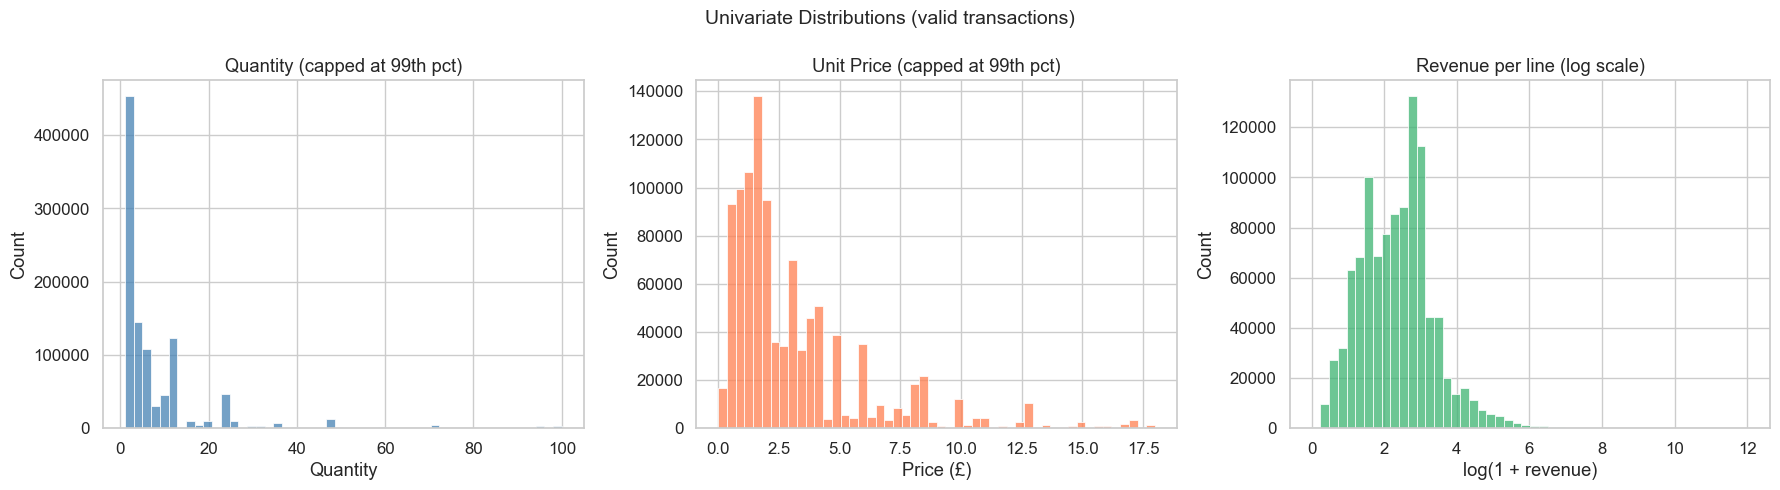

Saved → reports/01_univariate.png


In [3]:
# Add revenue column
df["revenue"] = df["quantity"] * df["price"]

# Work only with valid transactions for plots
df_valid = df[(df["quantity"] > 0) & (df["price"] > 0)].copy()
print(f"Valid transactions: {len(df_valid):,}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Univariate Distributions (valid transactions)", fontsize=14)

# Plot 1 — Quantity distribution (capped at 99th percentile)
q99 = df_valid["quantity"].quantile(0.99)
sns.histplot(
    df_valid[df_valid["quantity"] <= q99]["quantity"],
    bins=50, ax=axes[0], color="steelblue"
)
axes[0].set_title("Quantity (capped at 99th pct)")
axes[0].set_xlabel("Quantity")

# Plot 2 — Price distribution (capped at 99th percentile)
p99 = df_valid["price"].quantile(0.99)
sns.histplot(
    df_valid[df_valid["price"] <= p99]["price"],
    bins=50, ax=axes[1], color="coral"
)
axes[1].set_title("Unit Price (capped at 99th pct)")
axes[1].set_xlabel("Price (£)")

# Plot 3 — Revenue per line item (log scale)
sns.histplot(
    np.log1p(df_valid["revenue"]),
    bins=50, ax=axes[2], color="mediumseagreen"
)
axes[2].set_title("Revenue per line (log scale)")
axes[2].set_xlabel("log(1 + revenue)")

plt.tight_layout()
plt.savefig("../reports/01_univariate.png", dpi=150)
plt.show()
print("Saved → reports/01_univariate.png")

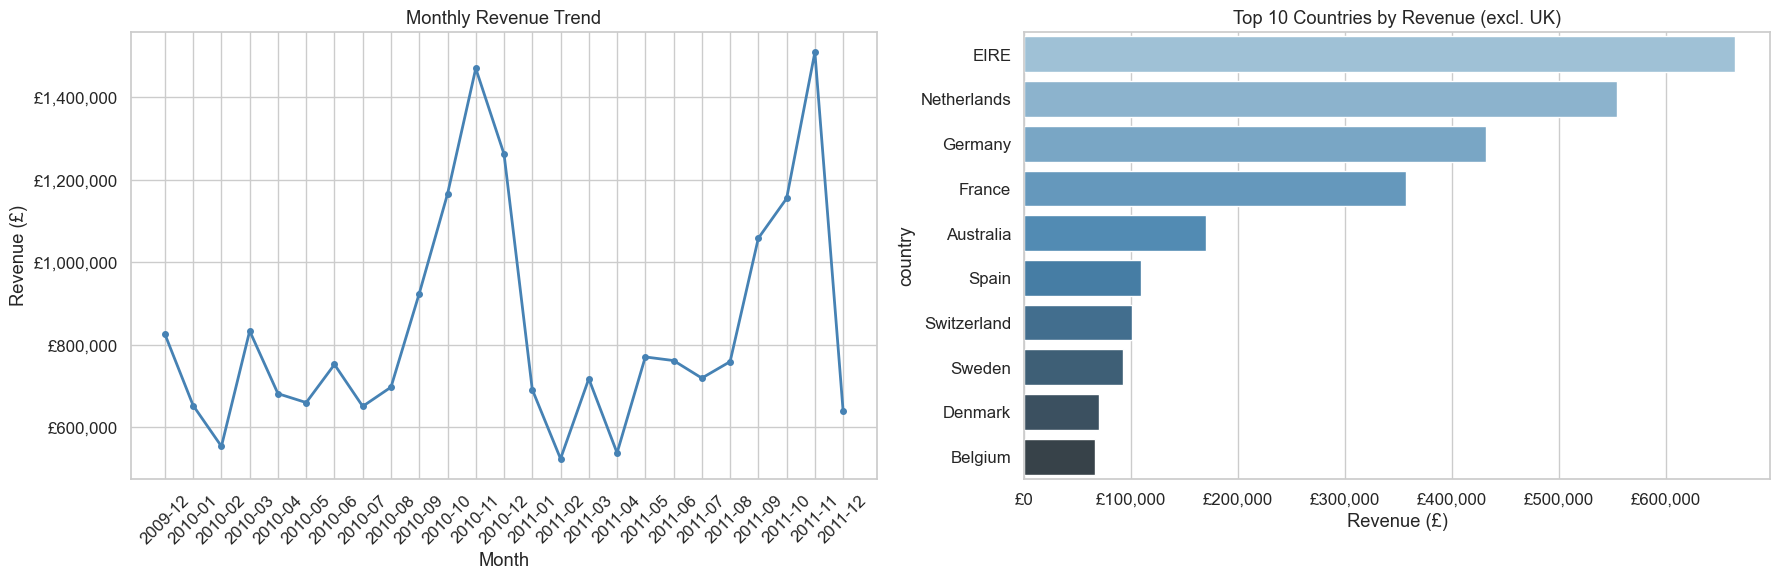

Saved → reports/02_bivariate.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1 — Monthly revenue trend
monthly = (
    df_valid.groupby(df_valid["invoicedate"].dt.to_period("M"))["revenue"]
    .sum()
    .reset_index()
)
monthly["invoicedate"] = monthly["invoicedate"].astype(str)

axes[0].plot(
    monthly["invoicedate"], monthly["revenue"],
    marker="o", linewidth=2, color="steelblue", markersize=4
)
axes[0].set_title("Monthly Revenue Trend")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Revenue (£)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}")
)

# Plot 2 — Top 10 countries by revenue (excluding UK)
country_rev = (
    df_valid[df_valid["country"] != "United Kingdom"]
    .groupby("country")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
sns.barplot(
    data=country_rev, x="revenue", y="country",
    ax=axes[1], palette="Blues_d"
)
axes[1].set_title("Top 10 Countries by Revenue (excl. UK)")
axes[1].set_xlabel("Revenue (£)")
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}")
)

plt.tight_layout()
plt.savefig("../reports/02_bivariate.png", dpi=150)
plt.show()
print("Saved → reports/02_bivariate.png")

In [5]:
print("══════════════════════════════════════════════════")
print("  HYPOTHESIS TEST 1: UK vs Non-UK Average Order Value")
print("══════════════════════════════════════════════════")

# Compute order-level AOV
order_aov = (
    df_valid.groupby(["invoice", "country"])["revenue"]
    .sum()
    .reset_index()
)
order_aov["is_uk"] = order_aov["country"] == "United Kingdom"

uk     = order_aov[order_aov["is_uk"]]["revenue"]
non_uk = order_aov[~order_aov["is_uk"]]["revenue"]

t_stat, p_value = stats.ttest_ind(uk, non_uk, equal_var=False)

print(f"UK     mean AOV : £{uk.mean():,.2f}  (n={len(uk):,})")
print(f"Non-UK mean AOV : £{non_uk.mean():,.2f}  (n={len(non_uk):,})")
print(f"T-statistic     : {t_stat:.4f}")
print(f"P-value         : {p_value:.6f}")
print(f"Conclusion      : {'Significant difference ✅' if p_value < 0.05 else 'No significant difference ❌'}")

print("\n══════════════════════════════════════════════════")
print("  HYPOTHESIS TEST 2: Return Rate by Region")
print("══════════════════════════════════════════════════")

# Group into UK vs Non-UK for chi-square
df["is_uk"]     = df["country"] == "United Kingdom"
df["is_return"] = df["quantity"] < 0

contingency = pd.crosstab(df["is_uk"], df["is_return"])
print("\nContingency Table:")
print(contingency)

chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi2 statistic  : {chi2:.4f}")
print(f"P-value         : {p_chi:.6f}")
print(f"Degrees of free : {dof}")
print(f"Conclusion      : {'Return rate differs by region ✅' if p_chi < 0.05 else 'No significant difference ❌'}")

══════════════════════════════════════════════════
  HYPOTHESIS TEST 1: UK vs Non-UK Average Order Value
══════════════════════════════════════════════════
UK     mean AOV : £489.14  (n=36,536)
Non-UK mean AOV : £875.67  (n=3,542)
T-statistic     : -12.1670
P-value         : 0.000000
Conclusion      : Significant difference ✅

══════════════════════════════════════════════════
  HYPOTHESIS TEST 2: Return Rate by Region
══════════════════════════════════════════════════

Contingency Table:
is_return   False  True 
is_uk                   
False       83197   2844
True       961224  20106

Chi2 statistic  : 593.0610
P-value         : 0.000000
Degrees of free : 1
Conclusion      : Return rate differs by region ✅


In [6]:
print("── Outlier Summary (IQR method) ────────────────")

for col in ["quantity", "price", "revenue"]:
    Q1  = df_valid[col].quantile(0.25)
    Q3  = df_valid[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_valid[(df_valid[col] < lower) | (df_valid[col] > upper)]
    print(f"{col:10s} → lower: {lower:,.2f} | upper: {upper:,.2f} | outliers: {len(outliers):,} ({100*len(outliers)/len(df_valid):.1f}%)")

── Outlier Summary (IQR method) ────────────────
quantity   → lower: -12.50 | upper: 23.50 | outliers: 111,341 (10.7%)
price      → lower: -3.07 | upper: 8.45 | outliers: 81,634 (7.8%)
revenue    → lower: -16.80 | upper: 38.40 | outliers: 85,727 (8.2%)


In [7]:
import sweetviz as sv
from pathlib import Path
import pandas as pd

# Load clean data
clean_df = pd.read_parquet("../data/retail_clean.parquet")

# Generate report — this takes ~1-2 minutes
report = sv.analyze(
    clean_df,
    target_feat="is_uk"          # analyse everything relative to UK vs non-UK
)

report.show_html("../reports/sweetviz_eda.html", open_browser=True)
print("Report saved → reports/sweetviz_eda.html")

                                             |                                                                …

Report ../reports/sweetviz_eda.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
Report saved → reports/sweetviz_eda.html
